In [ ]:
## start here Cleared kernal and run from start

In [1]:
import requests
import json
from pathlib import Path
from io import BytesIO
import openpyxl
import csv
import pickle
from pprint import pprint
from box_sdk_gen import BoxClient, BoxDeveloperTokenAuth

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot

from sklearn.model_selection import GroupKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score
from keras.regularizers import l2
from keras import optimizers

import tensorflow as tf
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential, Model
from keras.layers import Input, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, Activation, LSTM, Flatten, Concatenate,Bidirectional, GlobalMaxPooling1D, SpatialDropout1D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import backend as K

from itertools import product
import random
import warnings


#### Add session token

In [2]:

token = 'token_here' #Define Token 

auth = BoxDeveloperTokenAuth(token=token)
client = BoxClient(auth=auth)
HEADERS = {"Authorization": f"Bearer {token}"}

### Define Box read and write

In [3]:
def read_box_folder(path, start_id="0"):
    path_split = path.strip("/").split("/")
    folder_id = start_id

    # Walk through the folder path
    for folder_name in path_split:
        url = f"https://api.box.com/2.0/folders/{folder_id}/items?limit=1000"
        res = requests.get(url, headers=HEADERS)
        res.raise_for_status()
        data = res.json()

        matching = [f["id"] for f in data["entries"] if f["name"] == folder_name and f["type"] == "folder"]
        if not matching:
            raise ValueError(f"Folder not found: {folder_name}")
        folder_id = matching[0]

    # Collect all entries with pagination
    limit = 1000
    offset = 0
    entries = []

    while True:
        url = f"https://api.box.com/2.0/folders/{folder_id}/items?limit={limit}&offset={offset}"
        res = requests.get(url, headers=HEADERS)
        res.raise_for_status()
        data = res.json()

        entries.extend([{"id": f["id"], "name": f["name"], "type": f["type"]} for f in data["entries"]])

        if offset + limit >= data["total_count"]:
            break
        offset += limit

    return pd.DataFrame(entries)
    
def read_box_file(path, filename):
    folder_contents = read_box_folder(path)
    file_row = folder_contents[(folder_contents["name"] == filename) & (folder_contents["type"] == "file")]
    if file_row.empty:
        raise ValueError(f"File not found: {filename}")
    
    file_id = file_row.iloc[0]["id"]
    download_url = f"https://api.box.com/2.0/files/{file_id}/content"
    
    res = requests.get(download_url, headers=HEADERS)
    res.raise_for_status()
    
    # Save to temporary file (or keep in memory)
    tmp_path = Path(f"/tmp/{filename}")
    tmp_path.write_bytes(res.content)
    
    return tmp_path


def read_box_pickle(path, filename):
    folder_contents = read_box_folder(path)
    file_row = folder_contents[(folder_contents["name"] == filename) & (folder_contents["type"] == "file")]
    if file_row.empty:
        raise ValueError(f"File not found: {filename}")
    
    file_id = file_row.iloc[0]["id"]
    download_url = f"https://api.box.com/2.0/files/{file_id}/content"
    
    res = requests.get(download_url, headers=HEADERS)
    res.raise_for_status()
    
    data = pickle.loads(res.content)
    
    return data


def write_box_file(df, folder_id, box_filename):
    # Save DataFrame to a temporary file
    tmp_path = Path(f"/tmp/{box_filename}")
    df.to_excel(tmp_path, index=False)

    url = "https://upload.box.com/api/2.0/files/content"
    attributes = json.dumps({"name": box_filename, "parent": {"id": folder_id}})
    files = {
        "attributes": (None, attributes, "application/json"),
        "file": (box_filename, tmp_path.read_bytes(), "application/vnd.openxmlformats-officedocument.spreadsheetml.sheet") }

    res = requests.post(url, headers=HEADERS, files=files)
    
    tmp_path.unlink()  # delete temp file

    if res.status_code == 201:
        print("File uploaded successfully!")
    else:
        raise RuntimeError(f"Upload failed: {res.text}")


def write_box_pickle(data_dict, folder_id, box_filename):
    # Save DataFrame to a temporary file
    tmp_path = Path(f"/tmp/{box_filename}")
    
    with open(tmp_path, 'wb') as f:
        pickle.dump(data_dict, f)

    url = "https://upload.box.com/api/2.0/files/content" 
    attributes = json.dumps({"name": box_filename, "parent": {"id": folder_id}})
    files = {
        "attributes": (None, attributes, "application/json"),
        "file": (box_filename, tmp_path.read_bytes(), "application/octet-stream") }

    res = requests.post(url, headers=HEADERS, files=files)
    
    tmp_path.unlink() # delete temp file

    if res.status_code == 201:
        print(f"Successfully uploaded {box_filename} to Box!")
    else:
        raise RuntimeError(f"Upload failed: {res.status_code} - {res.text}")




# Plotting 

def plot_normality(data, var_unnormalized, var_normalized, xlim1 = (None,None), ylim1 = (None,None), xlim2 = (None, None), ylim2 = (None, None)):
    fig, axes = plt.subplots (2,2, figsize = (8,5))
    
    sns.histplot(data, x=var_unnormalized, color='green', fill=True, ax=axes[0,0])
    axes[0,0].set_title("Unnormalized Hist")
    axes[0,0].set_ylabel('Density')
    axes[0,0].set_xlim(xlim1)
    axes[0,0].set_ylim(ylim1)
    
    
    sns.histplot(data, x=var_normalized, color='blue', fill=True, ax=axes[0,1])
    axes[0,1].set_title("Normalized Hist")
    axes[0,1].set_ylabel('Density')
    axes[0,1].set_xlim(xlim2)
    axes[0,1].set_ylim(ylim2)
    
    
    qqplot(data[var_unnormalized], line='s',ax=axes[1,0])
    axes[1,0].set_title("Unnormalized QQPlot")
    
    
    qqplot(data[var_normalized], line='s',ax=axes[1,1])
    axes[1,1].set_title("Normalized QQPlot")
    
    plt.tight_layout()
    return plt.show() 


# F1 metric
import tensorflow as tf

def f1_metric(y_true, y_pred):
    # 1. Round predictions using tf.round instead of K.round
    y_pred = tf.cast(tf.round(y_pred), 'float32')
    y_true = tf.cast(y_true, 'float32')
    
    # 2. Calculate components
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    # 3. Precision and Recall
    # We use tf.math.divide_no_nan to avoid division by zero crashes
    precision = tf.math.divide_no_nan(tp, tp + fp)
    recall = tf.math.divide_no_nan(tp, tp + fn)

    # 4. Final F1 Calculation
    f1 = tf.math.divide_no_nan(2 * precision * recall, precision + recall)
    
    return f1


In [4]:
def compute_pupil_z(df):
    df['p_mean'] = df.loc[df['gazepoint_valid'] == 1].groupby('ParticipantName')['PupilMean'].transform('mean')
    df['p_std'] = df.loc[df['gazepoint_valid'] == 1].groupby('ParticipantName')['PupilMean'].transform('std')
    df['pupil_z'] = (df['PupilMean'] - df['p_mean']) / (df['p_std'] + 1e-9)
    df.drop(columns=['p_mean','p_std'], inplace=True)
    return df

def scale_velocity(df, scaler=None, fit=True):
    df["vel_log"] = df["vel"].apply(lambda x: float(math.log1p(x)))
    if fit:
        scaler = MinMaxScaler()
        df["vel_log"] = scaler.fit_transform(df[["vel_log"]])
        return df, scaler
    else:
        df["vel_log"] = scaler.transform(df[["vel_log"]])
        return df

def pad_trial(trial_df, max_length):
    n_rows = len(trial_df)
    if n_rows < max_length:
        padding = pd.DataFrame(0, index=range(max_length - n_rows), columns=trial_df.columns)
        padding['ParticipantName'] = trial_df['ParticipantName'].iloc[0]
        padding['trial'] = trial_df['trial'].iloc[0]
        padding['n_steps_by_row'] = list(range(n_rows, max_length))
        trial_df = pd.concat([trial_df, padding], ignore_index=True)
    return trial_df

def build_X_y(df, features, outcome, mapping={'No SA':0,'SA':1}):
    df_sorted = df.sort_values(['ParticipantName','trial','n_steps_by_row'])
    trial_sequences = [group[features].values for _, group in df_sorted.groupby(['ParticipantName','trial'])]
    X = np.stack(trial_sequences)
    X = np.where(np.isnan(X), 0, X)
    y = np.array([group[outcome].iloc[0] for _, group in df_sorted.groupby(['ParticipantName','trial'])])
    y = np.array([mapping[val] for val in y]).astype('float32')
    return X, y



# --- Store results function ---
def store_results(results, experiment_id, model_details, outcome, X, cv_results,
                  participant_results, best_val_auc, roc_auc, histories, cr, cm):
    results[experiment_id] = {
        "model_details": model_details,
        "outcome": outcome,
        "n_samples": X.shape[0],
        "n_timesteps": X.shape[1],
        "n_features": X.shape[2],
        "variables": features,
        "cv_results": cv_results,
        "participant_results": participant_results,
        "best_val_auc": best_val_auc,
        "roc_auc": roc_auc,
        "fold_history": histories,
        "classification_report": cr,
        "confusion_matrix": cm
    }
    return results


### Reshape xlsx data

In [ ]:
#### Convert xlsx to dictionary, keys sorted by subject ID and individual trials

# # # Just need to do once. Result stored as 'subject_trial_df.pkl'

# #Read subject gaze files from Box
# Box_path = 'Freeview 2025/files from BEST folder/Data (from BEST_project on server)/Eyetracking Cleaned/Baseline_minimallyprocessed/20260227'
# folder_items = read_box_folder(Box_path)

# # Exclude summary statistic files
# subject_files = folder_items[
#     (folder_items["name"].str.endswith("_freeview_t1_processed.xlsx")) & 
#     (~folder_items["name"].str.startswith("summary_statistics"))]

# all_dfs = []

# for index, row in subject_files.iterrows():
#     filename = row["name"]
    
#     # Load the Excel file
#     tmp_path = read_box_file(Box_path, filename)
#     df = pd.read_excel(tmp_path)
#     all_dfs.append(df)
#     print(f"Completed: {filename}")

# # Concatenate all files
# long_df = pd.concat(all_dfs, ignore_index=True)

# print(f"Concatenated {len(all_dfs)} files into {len(long_df)} rows")

# pd.to_pickle(long_df, 'subject_trial_df.pkl')

### Load dfs

#### Load trial df 

In [5]:
# Load subject trial data
pkl_df = pd.read_pickle("subject_trial_df.pkl")

# Box_path = 'Freeview 2025/files from BEST folder/Data (from BEST_project on server)/Eyetracking Cleaned/Baseline_minimallyprocessed/20260227'
# full_df = read_box_pickle(Box_path, "subject_trial_df.pkl")

# Outcome/ Demographic/ CSSRS
df_summary_statistics_path = read_box_file('Freeview 2025/files from BEST folder/Data (from BEST_project on server)/Eyetracking Cleaned/Baseline_minimallyprocessed/20260227','summary_statistics_freeview_t1_processed.xlsx')
outcomes_data_path = read_box_file('Freeview 2025/files from BEST folder/Data (from BEST_project on server)/Eyetracking Cleaned','outcomes_data_calculated_2.15.26.xlsx')
cssrs_data_path = read_box_file('Freeview 2025/files from BEST folder/Data (from BEST_project on server)/Eyetracking Cleaned','cssrs_t1_2.7.26.xlsx')

#Read in summary stats / trial meta data
df_summary_statistics = pd.read_excel(df_summary_statistics_path)[['subject', 'TrialsKept', 'ExperimentVersion']] #remove group variable for later merge 


outcomes_data = pd.read_excel(outcomes_data_path)
cssrs_t1 = pd.read_excel(cssrs_data_path)

summary_statistics = df_summary_statistics.merge(outcomes_data, left_on='subject', right_on='ParticipantName')
summary_statistics = summary_statistics.merge(cssrs_t1, how = 'left', left_on='subject', right_on='PtID') 
summary_statistics = summary_statistics.drop('PtID', axis=1)
# summary_statistics = summary_statistics.dropna()

In [6]:
train_subjects_6mo = [236, 254, 139, 448, 338, 353, 171, 347, 276, 145, 164, 354, 279, 
                  253, 316, 363, 208, 137, 399, 125, 268, 346, 118, 149, 269, 283, 
                  410, 373, 258, 400, 274, 237, 153, 295, 292, 303, 391, 244, 251, 
                  325, 351, 357, 199, 187, 345, 326, 194, 144, 238, 332, 180, 136, 
                  206, 334, 426, 291, 435, 423, 214, 430, 252, 148, 138, 277, 160, 
                  150, 165, 317, 356, 349, 256, 321, 282, 377, 203, 223, 288, 205, 
                  318, 371, 300, 190, 246, 359, 310, 337, 362, 440, 174, 226, 372, 
                  158, 379, 294, 366, 231, 367, 439, 278]

test_subjects_6mo = [380, 420, 210, 197, 230, 368, 401, 324, 133, 121, 161, 245, 434, 
                 221, 271, 192, 296, 290, 382, 350, 229, 413, 193, 417, 170, 365, 299, 
                 428, 320, 264, 327, 173, 322, 408, 329, 298, 341, 443, 124, 449, 189, 
                 339, 414]


train_subjects_3wk = [153, 160, 327, 320, 334, 208, 271, 303, 322, 439, 237, 118, 223, 
                      324, 435, 318, 197, 161, 238, 321, 298, 341, 440, 253, 339, 316, 
                      366, 391, 337, 329, 365, 276, 299, 171, 137, 199, 310, 230, 288, 
                      349, 158, 282, 149, 145, 144, 377, 174, 345, 136, 205, 274, 258, 
                      399, 423, 351, 434, 170, 401, 325, 187, 244, 367, 192, 408, 138, 
                      125, 443, 359, 203, 148, 357, 373, 426, 194, 372, 139, 317, 379, 
                      268, 290, 356, 294, 448, 246, 283, 380, 226, 346, 256, 180, 353, 
                      231, 210, 414, 173, 150, 254, 279, 264]

test_subjects_3wk = [278, 206, 413, 410, 291, 417, 420, 362, 400, 428, 236, 245, 332, 
                     382, 269, 326, 363, 133, 449, 251, 295, 347, 300, 165, 189, 190, 
                     371, 214, 368, 430, 277, 338, 164, 221, 350, 252, 354, 124, 229, 
                     193, 292, 296, 121]

outcome = 'outcome_t3_R'

In [7]:
# Define outcome of interest 
train_subjects = train_subjects_6mo
test_subjects = test_subjects_6mo


df = pkl_df[(pkl_df['trial_valid'] == 1) & 
    (pkl_df['trial_length_valid'] == 1) &
    ((pkl_df['ParticipantName'].isin(train_subjects)) |
    (pkl_df['ParticipantName'].isin(test_subjects)))].copy()

df = df.merge(summary_statistics,how='right').copy()
df = df.drop('subject', axis=1)



#### Outcomes transformations

In [8]:
# Outcomes recoding
df['outcome_t3_R'] = df['outcome_t3'].replace({"Control": "No SA", "SI": "No SA"})
df['outcome_t2_R'] = df['outcome_t2'].replace({"Control": "No SA", "SI": "No SA"})
df['outcome_t1_R'] = df['outcome_t1'].replace({"Control": "No SA", "SI": "No SA"})
df['outcome_past3mo_t1_R'] = df['outcome_past3mo_t1'].replace({"Control": "No SA", "SI": "No SA"})


# One Hot Encode Image Type info  
df = pd.get_dummies(df, columns=['ImageType', 'DEMGB001'], dtype=int).copy()
df = df.rename(columns = {'DEMGB001_1.0':'Female','DEMGB001_2.0':'Male','DEMGB002':'Age'})


In [9]:
# # Split df into train, test 
#Train 
df_train = df[df['ParticipantName'].isin(train_subjects)].copy()

#Test Set
df_test = df[df['ParticipantName'].isin(test_subjects)].copy()

print('Train participants:', len(df_train['ParticipantName'].unique()))
print('Test participants: ',len(df_test['ParticipantName'].unique()))


Train participants: 99
Test participants:  43


In [ ]:
print(df_train.groupby('ParticipantName')[outcome].first().value_counts())
print(df_test.groupby('ParticipantName')[outcome].first().value_counts())

In [10]:
demo_features = ['Age','Male','Female', 'TrialsKept','CS24_LT_t1','CS12_1mo_t1']


#Define test demographics
participant_demo_test = df_test.groupby('ParticipantName')[demo_features].first()
participant_demo_test['CS24_LT_t1_log'] = participant_demo_test["CS24_LT_t1"].apply(lambda x: float(math.log1p(x)))
participant_demo_test = participant_demo_test.drop('CS24_LT_t1', axis = 1)


#Define train demographics
participant_demo_train_all = df_train.groupby('ParticipantName')[demo_features].first()

participant_demo_train_all['CS24_LT_t1_log'] = participant_demo_train_all["CS24_LT_t1"].apply(lambda x: float(math.log1p(x)))
participant_demo_train_all = participant_demo_train_all.drop('CS24_LT_t1', axis = 1)

demo_categorical_features = ['Male','Female']
demo_numeric_features = [col for col in participant_demo_train_all.columns if col not in demo_categorical_features]




features = [
    'GazeX_clean_norm', 'GazeY_clean_norm', 
    'gazepoint_valid', 
    'pupil_z_scaled', 
    #'vel_log',
    'ImageType_Background', 'ImageType_Dysphoric', 'ImageType_Neutral','ImageType_Social', 
    'ImageType_Suicide'
]



In [11]:
results={}
counter = 1

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# === Define model name and parameters === 

filters1 = 32
kernel1 = 7
strides1 = 1
dilation1 = 1

filters2 = 64
kernel2 = 5
strides2 = 1
dilation2 = 1


filters3 = 128
kernel3 = 3
strides3 = 1
dilation3 = 1


dense = 32
dropout = .3
pool1 = 8


experiment_id = f'{counter}) {outcome} Pupil XY demo'


# === Set up CV === 
participants = np.unique(df_train['ParticipantName'])
participant_labels = (
    df_train.groupby('ParticipantName')[outcome]
    .first()
    .values
)

# # Stratify by  outcome 
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
all_val_preds = []
all_val_true = []
histories = []
all_fold_results = []


for fold, (train_idx, val_idx) in enumerate(kf.split(participants, participant_labels), 1):
    
    print(f"Fold {fold} starting...")

    # # Split training and validation folds
    train_subjects = participants[train_idx]
    val_subjects = participants[val_idx]

    # # Define training and validation dfs
    df_train_fold = df_train[df_train['ParticipantName'].isin(train_subjects)].copy()
    df_val_fold = df_train[df_train['ParticipantName'].isin(val_subjects)].copy()

    
    trial_participants_train = (
        df_train_fold
        .groupby(['ParticipantName','trial'])
        .first()
        .index
        .get_level_values('ParticipantName'))

    trial_participants_val = (
        df_val_fold
        .groupby(['ParticipantName','trial'])
        .first()
        .index
        .get_level_values('ParticipantName'))


    # === Pre process Gaze: train fold and validation fold separately to avoid leakeage ===
    # # Z score and scale pupil
    df_train_fold = compute_pupil_z(df_train_fold)
    df_val_fold = compute_pupil_z(df_val_fold)
    
    pupil_scaler = MinMaxScaler()
    df_train_fold['pupil_z_scaled'] = pupil_scaler.fit_transform(df_train_fold[['pupil_z']])
    df_val_fold['pupil_z_scaled'] = pupil_scaler.transform(df_val_fold[['pupil_z']])

    # # Scale velocity
    df_train_fold, vel_scaler = scale_velocity(df_train_fold, fit=True)
    df_val_fold = scale_velocity(df_val_fold, scaler=vel_scaler, fit=False)


    # # Scale gaze XY
    gaze_scaler = MinMaxScaler()
    df_train_fold[['GazeX_clean_norm','GazeY_clean_norm']] = gaze_scaler.fit_transform(
        df_train_fold[['GazeX_clean','GazeY_clean']])
    df_val_fold[['GazeX_clean_norm','GazeY_clean_norm']] = gaze_scaler.transform(
        df_val_fold[['GazeX_clean','GazeY_clean']])

    
    # === Prep arrays for CNN === 
    
    # # Pad trial lengths
    max_length_fold = max(
        df_train_fold.groupby(['ParticipantName','trial']).size().max(),
        df_val_fold.groupby(['ParticipantName','trial']).size().max()
    )
    
    df_train_fold = df_train_fold.groupby(['ParticipantName','trial'], group_keys=False).apply(pad_trial, max_length=max_length_fold)
    df_val_fold = df_val_fold.groupby(['ParticipantName','trial'], group_keys=False).apply(pad_trial, max_length=max_length_fold)
    

    # # Covert to array
    X_train_fold, y_train_fold = build_X_y(df_train_fold, features, outcome)
    X_val_fold, y_val_fold = build_X_y(df_val_fold, features, outcome)

    
    # === Compute class weights for training and validation ===
    classes = np.unique(y_train_fold)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_fold)
    class_weights = dict(zip(classes, weights))
    


    # === Pre process Demographics: train fold and validation fold separately to avoid leakeage ===
    participant_demo_train_fold = participant_demo_train_all.loc[train_subjects].copy()
    participant_demo_val_fold   = participant_demo_train_all.loc[val_subjects].copy()

    # if 'CS12_1mo_t1' in demo_features:
    #     SI_severity_scaler = MinMaxScaler()
    #     participant_demo_train_fold[['CS12_1mo_t1']] = SI_severity_scaler.fit_transform(
    #         participant_demo_train_fold[['CS12_1mo_t1']])
    #     participant_demo_val_fold[['CS12_1mo_t1']] = SI_severity_scaler.transform(
    #         participant_demo_val_fold[['CS12_1mo_t1']])


    demo_scaler = StandardScaler()
    participant_demo_train_fold[demo_numeric_features] = demo_scaler.fit_transform(
        participant_demo_train_fold[demo_numeric_features])
    participant_demo_val_fold[demo_numeric_features] = demo_scaler.transform(
        participant_demo_val_fold[demo_numeric_features])

    demo_cols = demo_numeric_features + demo_categorical_features
    
    X_demo_train = participant_demo_train_fold.loc[trial_participants_train, demo_cols].to_numpy()
    X_demo_val = participant_demo_val_fold.loc[trial_participants_val, demo_cols].to_numpy()



    
# ==============================  CNN ==============================  
    K.clear_session()
    n_timesteps = X_train_fold.shape[1]
    n_features = X_train_fold.shape[2]

    n_demo_features = X_demo_train.shape[1]

    
    eye_input = Input(shape=(n_timesteps, n_features),name='eye_input')
    demo_input = Input(shape=(n_demo_features,),name = 'demo_input')

    x = Conv1D(filters = filters1,kernel_size=kernel1, dilation_rate=dilation1, strides= strides1,kernel_regularizer=l2(.01))(eye_input)
    x = Activation('relu')(x)
    
    x = Conv1D(filters = filters2,kernel_size=kernel2, dilation_rate=dilation2, strides= strides2,kernel_regularizer=l2(.01))(x)
    x = Activation('relu')(x)

    x = Conv1D(filters = filters3,kernel_size=kernel3, dilation_rate=dilation3, strides= strides3,kernel_regularizer=l2(.01))(x)
    x = Activation('relu')(x)

    x = MaxPooling1D(pool_size=pool1)(x)
    
    x = Bidirectional(LSTM(64, dropout=0.2))(x)
    
    x = Concatenate()([x,demo_input])
    
    x = Dense(dense, activation="relu")(x)

    output = Dense(1, activation="sigmoid")(x)

    model = Model(
        inputs = [eye_input, demo_input],
        outputs = output
    )
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0003),
        loss = tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )


# =================================  Training =================================
    
    early_stop = EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)

    
    history = model.fit(
        [X_train_fold, X_demo_train],
        y_train_fold,
        validation_data = ([X_val_fold, X_demo_val], y_val_fold),
        epochs=30,
        batch_size=64,
        class_weight = class_weights,
        verbose=0,
        callbacks= [early_stop] #, reduceLR]
    )

    # # Store y and predictions 
    val_preds = model.predict([X_val_fold, X_demo_val]).ravel()
    val_participant_ids = df_val_fold.groupby(['ParticipantName','trial']).first().index.get_level_values('ParticipantName').values

    fold_results = pd.DataFrame({
        "ParticipantName": val_participant_ids,
        "pred": val_preds,
        "y": y_val_fold
    })

    all_fold_results.append(fold_results)

    # # Store each epoches best 
    best_val_auc = max(history.history['val_auc'])
    cv_results.append(best_val_auc)
    histories.append(history.history)
    
    print(f"Fold {fold} best val_auc: {best_val_auc:.3f}")


print(f"Mean CV val_auc: {np.mean(cv_results):.3f}")


# # Store for CM and classificaiton report 
prob_value = 0.5

all_results = pd.concat(all_fold_results, ignore_index=True)
participant_results = (
    all_results
    .groupby("ParticipantName")
    .agg({"pred": "mean", "y": "first"})
)

y_true = participant_results["y"].values
y_pred_probs = participant_results["pred"].values
y_pred = (y_pred_probs >= prob_value).astype(int)


cr = classification_report(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)


fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)
print(f"Aggregated per-participant ROC AUC: {roc_auc:.3f}")


results = store_results(
    results=results,
    experiment_id=experiment_id,
    model_details=model.get_config(),
    outcome=outcome,
    X=X_train_fold,  # or X if you want full dataset info
    cv_results=cv_results,
    participant_results=participant_results,
    best_val_auc=np.mean(cv_results),
    roc_auc=roc_auc,
    histories=histories,
    cr=cr,
    cm=cm
)

# Access stored results:
# print(results[experiment_id]["classification_report"])
# print(results[experiment_id]["confusion_matrix"])


counter = counter + 1

In [ ]:
best_model_rocauc, best_value_rocauc = max(
    ((m, r['roc_auc']) for m, r in results.items()),
    key=lambda x: x[1])


print('Best model:', best_model_rocauc)
# print("Best model details:",  results[best_model_rocauc]['model_details'])
print('Best model val_auc:', np.round(results[best_model_rocauc]['best_val_auc'],3))
print('Best model roc auc:', np.round(best_value_rocauc,3))


0.7565610859728507


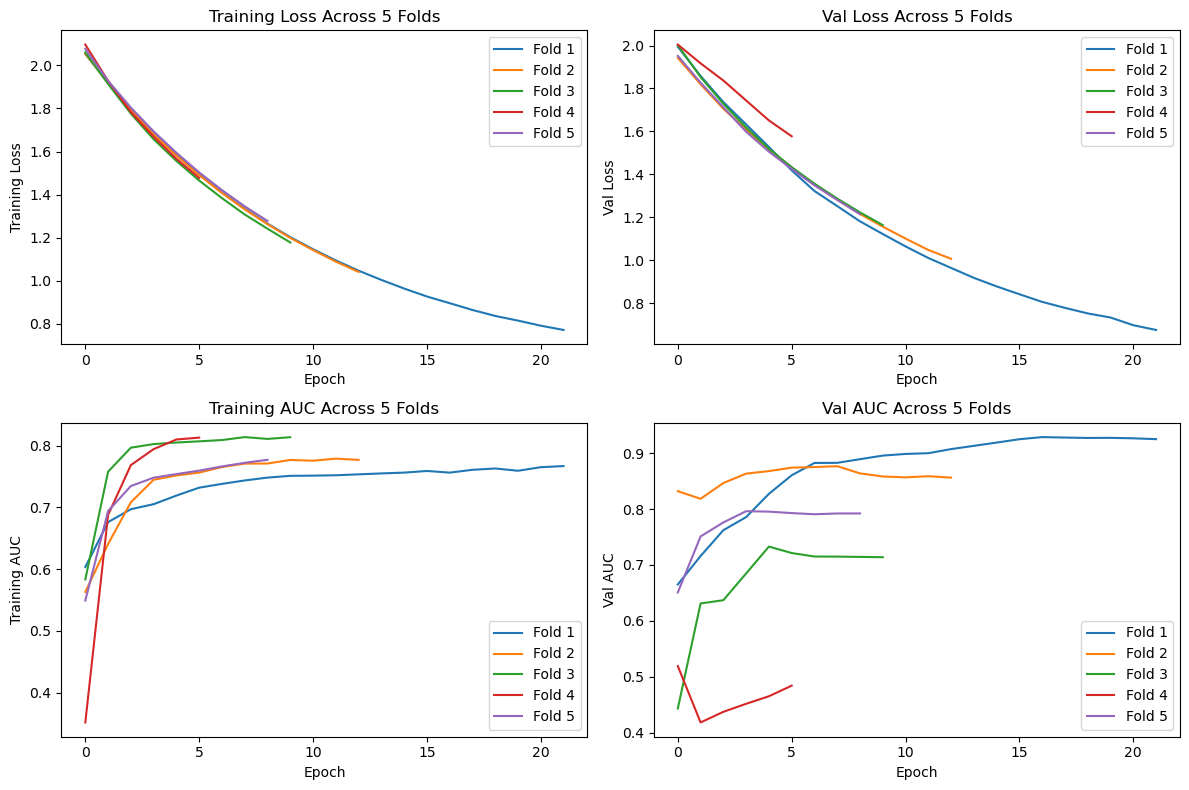

In [14]:

res = results['1) outcome_t3_R Pupil XY demo']

print(res['roc_auc'])

# plt.figure(figsize=(8,5))
fig, axes = plt.subplots(2,2, figsize = (12,8))

# 
for i, history in enumerate(res['fold_history'], 1):
    axes[0,0].plot(history['loss'], label=f'Fold {i}')

axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Training Loss')
axes[0,0].set_title('Training Loss Across 5 Folds')
axes[0,0].legend()


for i, history in enumerate(res['fold_history'], 1):
    axes[0,1].plot(history['val_loss'], label=f'Fold {i}')

axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Val Loss')
axes[0,1].set_title('Val Loss Across 5 Folds')
axes[0,1].legend()


for i, history in enumerate(res['fold_history'], 1):
    axes[1,0].plot(history['auc'], label=f'Fold {i}')

axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Training AUC')
axes[1,0].set_title('Training AUC Across 5 Folds')
axes[1,0].legend()


for i, history in enumerate(res['fold_history'], 1):
    axes[1,1].plot(history['val_auc'], label=f'Fold {i}')

axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Val AUC')
axes[1,1].set_title('Val AUC Across 5 Folds')
axes[1,1].legend()

plt.tight_layout()
plt.show()




In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eye_input           │ (None, 9185, 9)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 9179, 32)  │      2,048 │ eye_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 9179, 32)  │          0 │ conv1d[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 9175, 64)  │     10,304 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 9175, 64)  │          0 │ conv1d_1[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 9173, 128) │     24,704 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 9173, 128) │          0 │ conv1d_2[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1146, 128) │          0 │ activation_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     98,816 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demo_input          │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 134)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ demo_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,320 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,677 (1.60 MB)

 Trainable params: 140,225 (547.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 280,452 (1.07 MB)

Fold AUCs: [0.928819477558136, 0.8767380118370056, 0.7328976392745972, 0.519029438495636, 0.7962097525596619]
Mean AUC: 0.7707388639450073
Std AUC: 0.14259288836794226


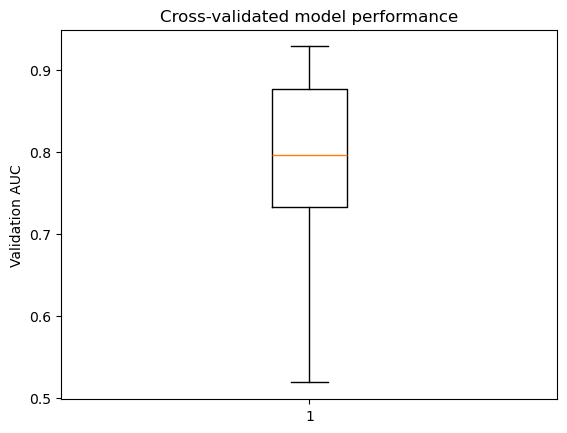

In [17]:
print("Fold AUCs:", cv_results)
print("Mean AUC:", np.mean(cv_results))
print("Std AUC:", np.std(cv_results))



plt.boxplot(cv_results)
plt.ylabel("Validation AUC")
plt.title("Cross-validated model performance")
plt.show()

Classification Report (per participant):
              precision    recall  f1-score   support

         0.0       0.81      0.71      0.75        65
         1.0       0.55      0.68      0.61        34

    accuracy                           0.70        99
   macro avg       0.68      0.69      0.68        99
weighted avg       0.72      0.70      0.70        99



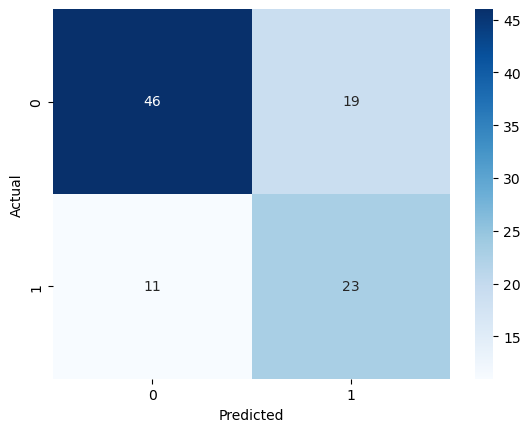

In [18]:
from sklearn.metrics import classification_report, confusion_matrix


# Threshold predictions to get binary labels
y_true = participant_results["y"].values
y_pred = (participant_results["pred"].values >= 0.5).astype(int)

# Classification report
print("Classification Report (per participant):")
print(classification_report(y_true, y_pred))

# Confusion matrix
# cm = confusion_matrix(y_true, y_pred)

# print("Confusion Matrix (per participant):")
# print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()